In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("customer_segmentation.csv")
data.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,...,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,...,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,...,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,...,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,...,20,1,0,0,0,0,0,3,11,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [27]:
data["Income"].isna().sum()

24

In [28]:
data.groupby(["Education", "Marital_Status"]).size().reset_index(name="Count")

,Education,Marital_Status,Count
0,2n Cycle,Divorced,23
1,2n Cycle,Married,81
2,2n Cycle,Single,37
3,2n Cycle,Together,57
4,2n Cycle,Widow,5
5,Basic,Divorced,1
6,Basic,Married,20
7,Basic,Single,18
8,Basic,Together,14
9,Basic,Widow,1


In [48]:
data["Income"] = data.groupby(["Education", "Marital_Status"])["Income"].transform(lambda x: x.fillna(x.median()))

In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [70]:
from datetime import date
data["age"] = (date.today().year - data["Year_Birth"])

In [78]:
data["Total_spending"] = data[["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]].sum(axis=1)

In [76]:
data["Total_children"] = data["Kidhome"] + data["Teenhome"]

In [98]:
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], dayfirst=True)
data["Customer_since"] = (pd.Timestamp.today() - data["Dt_Customer"]).dt.days

In [100]:
data[["Customer_since"]]

,Customer_since
0,5084
1,4534
2,4733
3,4560
4,4582
...,...
2235,4802
2236,4440
2237,4576
2238,4577


In [101]:
import seaborn as sns

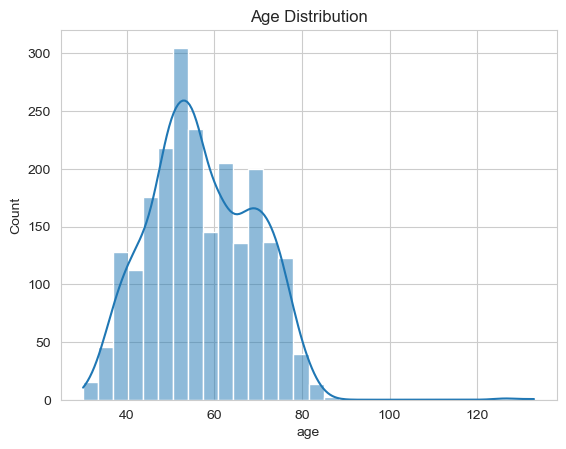

In [107]:
sns.histplot(data["age"], bins= 30, kde = True)
plt.title("Age Distribution")
plt.show()

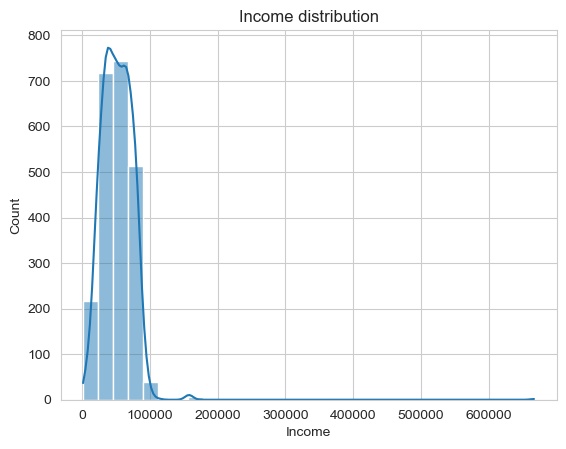

In [108]:
sns.histplot(data["Income"], bins = 30, kde=True)
plt.title("Income distribution")
plt.show()

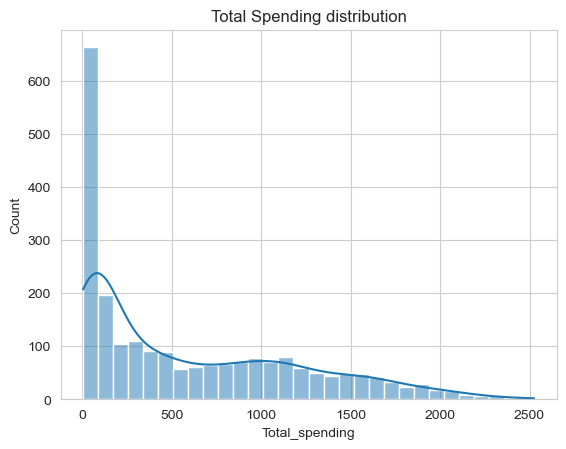

In [116]:
sns.histplot(data["Total_spending"], bins = 30, kde=True)
plt.title("Total Spending distribution")
plt.show()

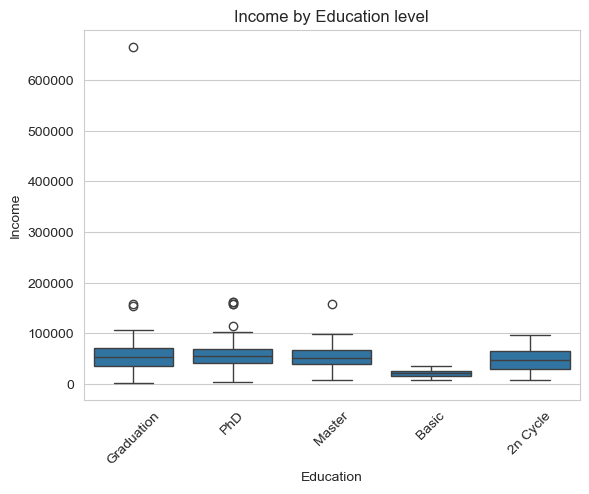

In [114]:
sns.boxplot(x = "Education", y = "Income", data=data)
plt.title("Income by Education level")
plt.xticks(rotation = 45)
plt.show()

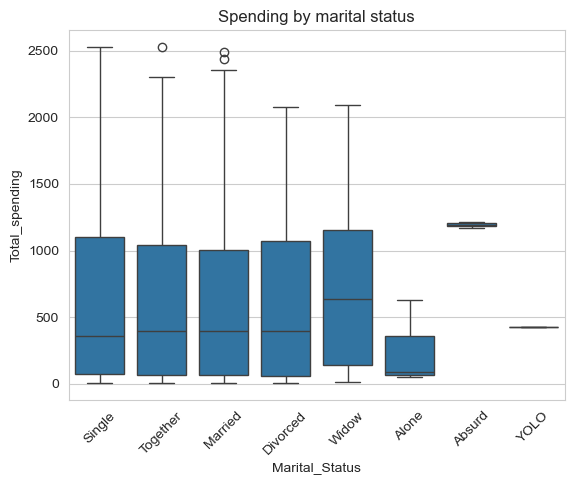

In [115]:
sns.boxplot(x = "Marital_Status", y = "Total_spending", data = data)
plt.xticks(rotation = 45)
plt.title("Spending by marital status")
plt.show()

In [117]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'age', 'month_total', 'Total_children', 'Total_spending',
       'Customer_since'],
      dtype='object')

In [118]:
corr_columns = ["Income", "age","Recency" , "Total_children", "Total_spending", "NumWebPurchases", "NumStorePurchases", "Customer_since"]

In [128]:
corr_df = data[corr_columns].corr()

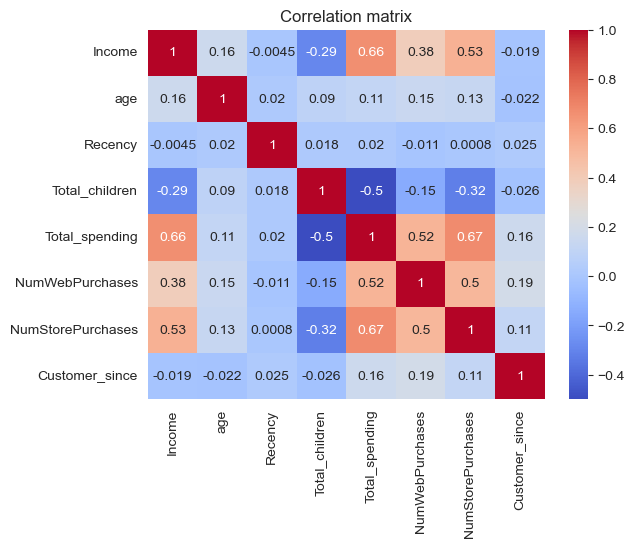

In [130]:
sns.heatmap(corr_df, annot=True, cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

In [135]:
pivot_income = pd.pivot_table(data=data, values="Income", index="Education", columns="Marital_Status", aggfunc="mean")
pivot_income

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.130435,46204.327160,53538.662162,44754.614035,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50799.674365,51290.071429,55752.251748,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52019.462264,57828.833333,NaN
PhD,NaN,35860.0,53096.615385,58127.026042,53251.010204,56047.529915,60288.083333,48432.0


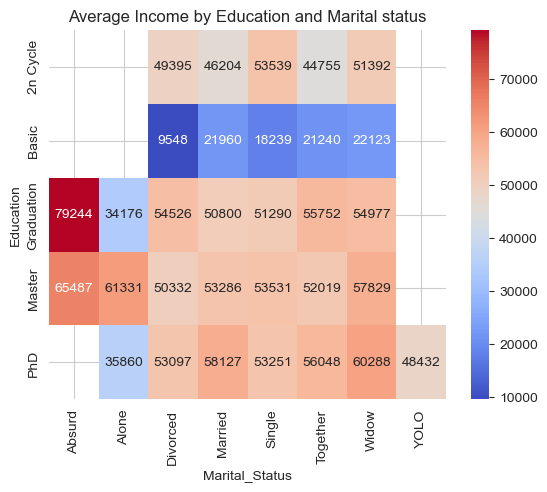

In [137]:
sns.heatmap(pivot_income, annot=True, fmt=".0f", cmap="coolwarm")
plt.title("Average Income by Education and Marital status")
plt.show()

In [140]:
group1 = data.groupby("Education")["Total_spending"].mean().sort_values(ascending=False)
group1

Education
PhD           672.409465
Graduation    619.898846
Master        611.781081
2n Cycle      496.527094
Basic          81.796296
Name: Total_spending, dtype: float64

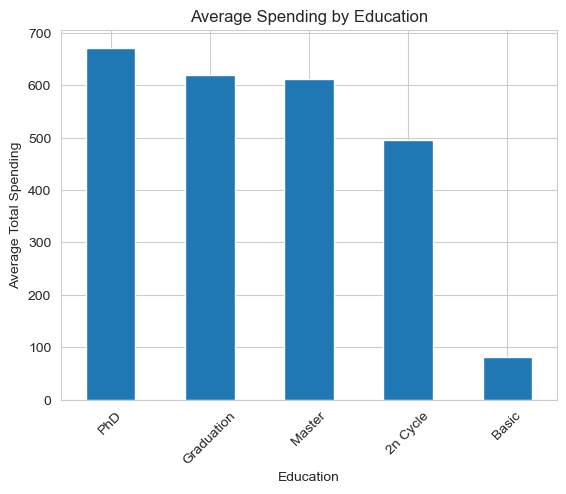

In [149]:
group1.plot(kind="bar")
plt.title("Average Spending by Education")
plt.ylabel("Average Total Spending")
plt.xticks(rotation = 45)
plt.show()

In [150]:
data["AcceptanceAny"] = data[["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response"]].sum(axis=1)

In [152]:
data["AcceptanceAny"] = data["AcceptanceAny"].apply(lambda x : 1 if x > 0 else 0)

In [165]:
group2 = data.groupby("Marital_Status")["AcceptanceAny"].mean().sort_values(ascending=False)

In [166]:
group2

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.350649
Alone       0.333333
Single      0.308333
Divorced    0.297414
Married     0.251157
Together    0.250000
Name: AcceptanceAny, dtype: float64

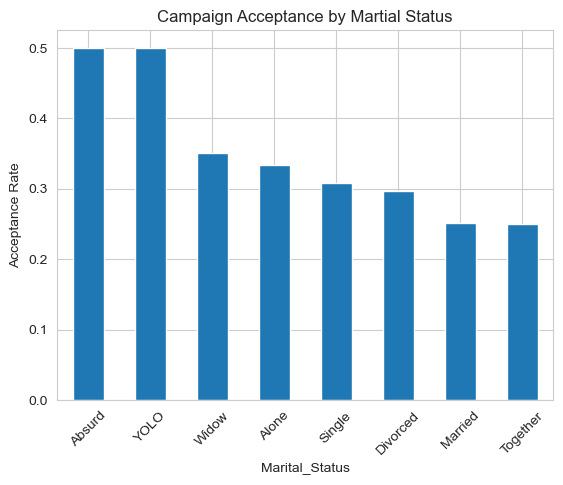

In [167]:
group2.plot(kind="bar")
plt.title("Campaign Acceptance by Martial Status")
plt.xticks(rotation = 45)
plt.ylabel("Acceptance Rate")
plt.show()

In [168]:
bins = [18, 30, 40, 50, 60, 70, 90]
labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]

In [169]:
data["AgeGroup"] = pd.cut(data["age"], bins=bins, labels=labels)

In [173]:
data[["AgeGroup"]]

,AgeGroup
0,60-69
1,70+
2,60-69
3,40-49
4,40-49
...,...
2235,50-59
2236,70+
2237,40-49
2238,60-69


In [176]:
group3 = data.groupby("AgeGroup")["Income"].mean().sort_values(ascending=True)

C:\Users\zoran\AppData\Local\Temp\ipykernel_16704\3434921963.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group3 = data.groupby("AgeGroup")["Income"].mean().sort_values(ascending=True)


In [177]:
group3

AgeGroup
18-29    10960.500000
30-39    47931.676471
40-49    48066.386364
50-59    50479.002920
60-69    55930.959350
70+      58674.326027
Name: Income, dtype: float64

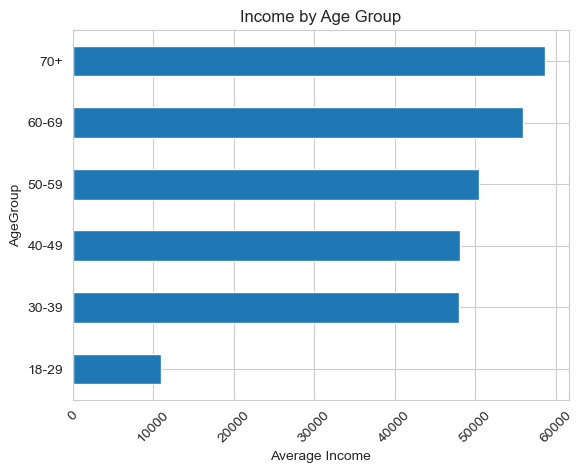

In [181]:
group3.plot(kind="barh")
plt.title("Income by Age Group")
plt.xticks(rotation = 45)
plt.xlabel("Average Income")
plt.show()

In [182]:
features = ["age", "Income", "Total_spending", "NumWebPurchases", "NumStorePurchases", "NumWebVisitsMonth", "Recency"]

In [188]:
X = data[features].copy()

In [189]:
X

,age,Income,Total_spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,69,58138.0,1617,8,4,7,58
1,72,46344.0,27,1,2,5,38
2,61,71613.0,776,8,10,4,26
3,42,26646.0,53,2,4,6,26
4,45,58293.0,422,5,6,5,94
...,...,...,...,...,...,...,...
2235,59,61223.0,1341,9,4,5,46
2236,80,64014.0,444,8,5,7,56
2237,45,56981.0,1241,2,13,6,91
2238,70,69245.0,843,6,10,3,8


In [190]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [191]:
X_scaled = scaler.fit_transform(X)

In [192]:
X_scaled

array([[ 0.98534473,  0.23592211,  1.67941681, ..., -0.55078479,
         0.69390374,  0.30703926],
       [ 1.23573295, -0.23519197, -0.96127545, ..., -1.1661254 ,
        -0.13046347, -0.38366418],
       [ 0.3176428 ,  0.77418412,  0.28267329, ...,  1.29523705,
        -0.54264708, -0.79808624],
       ...,
       [-1.01776106,  0.18970548,  1.05495122, ...,  2.21824797,
         0.28172013,  1.44669994],
       [ 1.06880747,  0.67959381,  0.39394775, ...,  1.29523705,
        -0.95483068, -1.41971934],
       [ 1.23573295,  0.02545068, -0.7204576 , ..., -0.55078479,
         0.69390374, -0.31459383]])

In [193]:
from sklearn.cluster import KMeans

In [194]:
wcss = []
for i in range(2,10):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [195]:
wcss

[10368.235374760727,
 9150.88573627397,
 8365.62247128557,
 7799.616627210904,
 7256.512402613689,
 6870.422819378055,
 6418.201706831943,
 6025.67116065581]

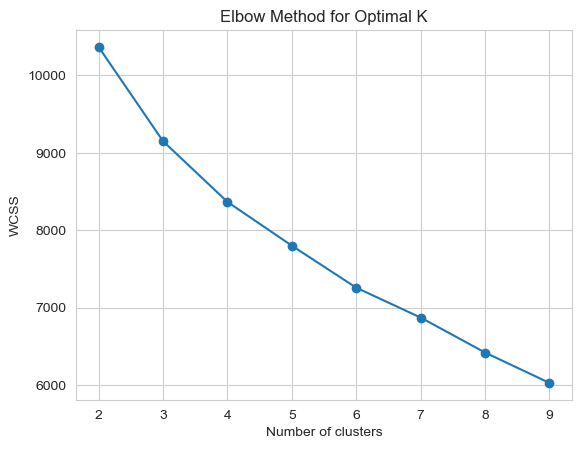

In [200]:
plt.plot(range(2,10), wcss, marker = "o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [201]:
kmeans = KMeans(n_clusters=6)
data["Cluster"] = kmeans.fit_predict(X_scaled)

In [203]:
data["Cluster"]

0       2
1       1
2       2
3       4
4       0
       ..
2235    2
2236    2
2237    3
2238    5
2239    1
Name: Cluster, Length: 2240, dtype: int32

In [216]:
data["Cluster"].value_counts()

Cluster
4    450
2    422
0    376
3    335
1    330
5    327
Name: count, dtype: int64

In [218]:
cluster_summary = data.groupby("Cluster")[features].mean()
cluster_summary

,age,Income,Total_spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,50.119681,32769.793883,114.587766,2.316489,3.178191,7.071809,76.470745
1,68.987879,43615.218182,174.245455,2.615152,4.021212,5.390909,52.530303
2,59.796209,59945.018957,894.924171,8.026066,7.874408,6.376777,45.845972
3,47.247761,77863.764179,1296.182090,4.561194,8.555224,2.647761,50.107463
4,49.733333,33109.118889,115.940000,2.180000,3.271111,6.648889,23.931111
5,70.525994,73408.688073,1199.847095,4.648318,8.522936,2.755352,52.033639


In [219]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
data["PCA1"], data["PCA2"] = pca_data[:,0], pca_data[:,1]

In [205]:
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Response,age,Total_children,Total_spending,Customer_since,AcceptanceAny,AgeGroup,Cluster,PCA1,PCA2
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,1,69,0,1617,5084,1,60-69,2,1.098478,-0.150541
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,72,2,27,4534,0,70+,1,-1.328285,0.355403
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,61,0,776,4733,0,60-69,2,1.875317,-0.998639
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,42,1,53,4560,0,40-49,4,-1.778795,-0.774007
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,45,1,422,4582,0,40-49,0,0.022150,1.152175
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,0,59,1,1341,4802,0,50-59,2,1.238345,-0.532187
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,0,80,3,444,4440,1,70+,2,0.495633,-0.005405
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,0,45,0,1241,4576,1,40-49,3,1.165754,1.054881
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,0,70,1,843,4577,0,60-69,5,1.886572,-1.098360


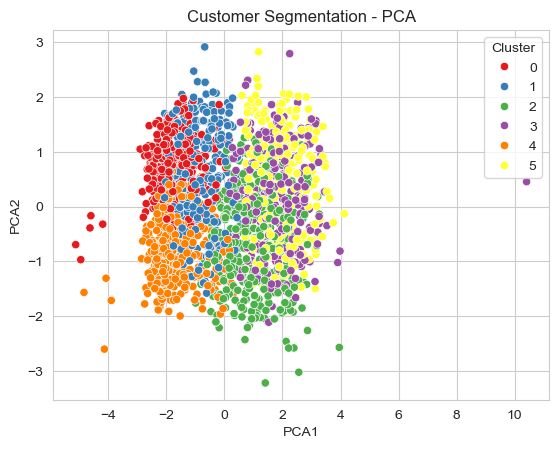

In [209]:
sns.scatterplot(data = data, x = "PCA1", y = "PCA2", hue="Cluster", palette="Set1")
plt.title("Customer Segmentation - PCA")
plt.show()

In [220]:
cluster_summary

,age,Income,Total_spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,50.119681,32769.793883,114.587766,2.316489,3.178191,7.071809,76.470745
1,68.987879,43615.218182,174.245455,2.615152,4.021212,5.390909,52.530303
2,59.796209,59945.018957,894.924171,8.026066,7.874408,6.376777,45.845972
3,47.247761,77863.764179,1296.182090,4.561194,8.555224,2.647761,50.107463
4,49.733333,33109.118889,115.940000,2.180000,3.271111,6.648889,23.931111
5,70.525994,73408.688073,1199.847095,4.648318,8.522936,2.755352,52.033639


In [221]:
cluster_names = {
    0: "Low-Spending Customers",
    1: "Older Low-Spending Customers",
    2: "High-Spending Customers",
    3: "Premium Customers",
    4: "Low-Spending Customers - Segment 2",
    5: "Affluent Older Customers"
}

data["Cluster_Description"] = data["Cluster"].map(cluster_names)

In [222]:
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,age,Total_children,Total_spending,Customer_since,AcceptanceAny,AgeGroup,Cluster,PCA1,PCA2,Cluster_Description
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,69,0,1617,5084,1,60-69,2,1.098478,-0.150541,High-Spending Customers
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,72,2,27,4534,0,70+,1,-1.328285,0.355403,Older Low-Spending Customers
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,61,0,776,4733,0,60-69,2,1.875317,-0.998639,High-Spending Customers
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,42,1,53,4560,0,40-49,4,-1.778795,-0.774007,Low-Spending Customers - Segment 2
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,45,1,422,4582,0,40-49,0,0.022150,1.152175,Low-Spending Customers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,59,1,1341,4802,0,50-59,2,1.238345,-0.532187,High-Spending Customers
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,80,3,444,4440,1,70+,2,0.495633,-0.005405,High-Spending Customers
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,45,0,1241,4576,1,40-49,3,1.165754,1.054881,Premium Customers
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,70,1,843,4577,0,60-69,5,1.886572,-1.098360,Affluent Older Customers


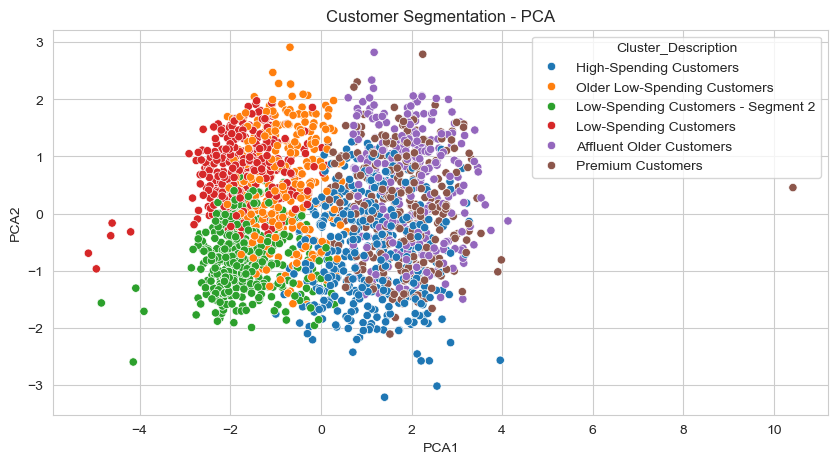

In [227]:
plt.figure(figsize=(10,5))
sns.scatterplot(data = data, x = "PCA1", y = "PCA2", hue="Cluster_Description")
plt.title("Customer Segmentation - PCA")
plt.show()